In [3]:
# Load the files
import numpy as np

# Load the data files
PV_mTCOff = np.load('PV_mTCOff.npy', allow_pickle=True)
PV_mTCOn = np.load('PV_mTCOn.npy', allow_pickle=True)
SST_mTCOff = np.load('SST_mTCOff.npy', allow_pickle=True)
SST_mTCOn = np.load('SST_mTCOn.npy', allow_pickle=True)

# Load the uniq frequencies
uniq_Freq = np.load('uniq_Freq.npy', allow_pickle=True)
octaves = np.log2(uniq_Freq)

# Load the facilitation and suppression indices for each
SST_facilitated_Ind = np.load('SST_facilitated_index.npy', allow_pickle=True)
SST_suppressed_Ind = np.load('SST_suppressed_index.npy', allow_pickle=True)
PV_facilitated_Ind = np.load('PV_facilitated_index.npy', allow_pickle=True)
PV_suppressed_Ind = np.load('PV_suppressed_index.npy', allow_pickle=True)


# Define gaussian and other functions

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

# define gaussian
def gaussian(x, a, mu, sigma, baseline):
    return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + baseline

def calculate_r2(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) < 2:
        return np.nan  # not enough points
    return r2_score(y_true[mask], y_pred[mask])

In [5]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

def fit_gaussians_to_tuning(
    mTC, octaves, *,
    min_points=3,
    sigma_init=0.5,     # default sigma guess (octaves)
    maxfev=8000
):
    """
    Fits a Gaussian (in octaves) to each column of mTC, trying multiple initializations.
    Allows negative amplitude for inhibited cells.
    Returns: DataFrame and predicted curves.
    """
    n_freqs, n_cells = mTC.shape
    results = []
    yhat_all = np.full_like(mTC, np.nan, dtype=float)

    mu_guess_global = float(np.median(octaves))

    for cell in range(n_cells):
        y = mTC[:, cell]
        mask = ~np.isnan(y)
        if np.count_nonzero(mask) < min_points:
            results.append((cell, np.nan, np.nan, np.nan, np.nan, np.nan, False))
            continue

        x_fit = octaves[mask]
        y_fit = y[mask]

        try:
            peak_idx = int(np.nanargmax(y)) 
            baseline_guess = float(np.nanmin(y))
            a_guess = float(y[peak_idx] - baseline_guess)  # can be negative if trough

            # Candidate parameter sets
            init_params = [
                [a_guess, mu_guess_global, sigma_init, baseline_guess],
                [a_guess, x_fit[peak_idx], sigma_init, baseline_guess],   # center at peak
                [a_guess, mu_guess_global, 1.0, baseline_guess],          # broader sigma
                [a_guess, mu_guess_global, 0.25, baseline_guess],         # narrower sigma
                [-abs(a_guess), mu_guess_global, sigma_init, baseline_guess]  # inverted (for trough-like)
            ]

            best_fit = None
            best_r2 = -np.inf

            for p0 in init_params:
                try:
                    popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0, maxfev=maxfev)
                    y_pred = gaussian(x_fit, *popt)
                    ss_res = np.sum((y_fit - y_pred) ** 2)
                    ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
                    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

                    if np.isfinite(r2) and r2 > best_r2:
                        best_fit = popt
                        best_r2 = r2
                except Exception:
                    continue

            if best_fit is not None:
                a, mu, sigma, baseline = best_fit
                yhat_all[:, cell] = gaussian(octaves, *best_fit)
                results.append((cell, a, mu, sigma, baseline, best_r2, True))
            else:
                results.append((cell, np.nan, np.nan, np.nan, np.nan, np.nan, False))

        except Exception as e:
            print(f"Fit failed for cell {cell}: {e}")
            results.append((cell, np.nan, np.nan, np.nan, np.nan, np.nan, False))

    df = pd.DataFrame(results, columns=['cell','a','mu','sigma','baseline','r2','success'])
    return df, yhat_all


# Compute fits for all the tuning curves (all)

In [6]:
# PV Light On
PV_results_on, PV_yhat_on = fit_gaussians_to_tuning(PV_mTCOn, octaves)

# PV Light Off
PV_results_off, PV_yhat_off = fit_gaussians_to_tuning(PV_mTCOff, octaves)

# SST Light On
SST_results_on, SST_yhat_on = fit_gaussians_to_tuning(SST_mTCOn, octaves)

# SST Light Off
SST_results_off, SST_yhat_off = fit_gaussians_to_tuning(SST_mTCOff, octaves)

/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2597702390.py:51: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0, maxfev=maxfev)


# Make PDFs

In [7]:
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl

# Assumes you already have:
# PV_results_off, PV_results_on : DataFrames with columns ['cell','a','mu','sigma','baseline','r2','success']
# mTCOff, mTCOn : arrays (n_freqs, n_cells)
# uniq_Freq : array of frequencies in Hz
# gaussian(x_oct, a, mu, sigma, baseline) where x_oct = log2(Hz)

pdf_filename = 'PV_receptivefield_fits_multipleguess.pdf'
freqs = uniq_Freq

# Index by cell for convenient lookup
off_df = PV_results_off.set_index('cell')
on_df  = PV_results_on.set_index('cell')

mTCOff = PV_mTCOff
mTCOn  = PV_mTCOn

# Cells present in both results
common_cells = sorted(set(off_df.index) & set(on_df.index))
with mpl.rc_context({
    'font.family': 'Arial',
    'font.size': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
}):
    with PdfPages(pdf_filename) as pdf:
        for cell in common_cells:
            row_off = off_df.loc[cell]
            row_on  = on_df.loc[cell]

            # Skip if either fit failed or has NaNs
            if (not row_off['success']) or (not row_on['success']):
                continue
            if np.any(np.isnan([row_off['a'], row_off['mu'], row_off['sigma'], row_off['baseline']])): 
                continue
            if np.any(np.isnan([row_on['a'], row_on['mu'], row_on['sigma'], row_on['baseline']])): 
                continue

            # Optional: enforce an R^2 cutoff
            # if (row_off['r2'] < 0.7) or (row_on['r2'] < 0.7):
            #     continue

            # What group is it in? 
            if cell in PV_facilitated_Ind:
                group_label = "Facilitated"
            elif cell in PV_suppressed_Ind:
                group_label = "Suppressed"
            else:
                group_label = "Neither"

            # Evaluate fits on a smooth octave grid, then plot in Hz
            fit_x_oct = np.linspace(np.log2(freqs.min()), np.log2(freqs.max()), 200)
            x_fit_hz = 2.0 ** fit_x_oct

            params_off = (row_off['a'], row_off['mu'], row_off['sigma'], row_off['baseline'])
            params_on  = (row_on['a'],  row_on['mu'],  row_on['sigma'],  row_on['baseline'])

            y_fit_off = gaussian(fit_x_oct, *params_off)
            y_fit_on  = gaussian(fit_x_oct, *params_on)

            # Raw data
            x_data = freqs
            y_data_off = mTCOff[:, cell]
            y_data_on  = mTCOn[:,  cell]

            # Plot
            fig, ax = plt.subplots(figsize=(2.2, 2.2))

            # Light Off
            ax.plot(x_data, y_data_off, 'o', color='grey', label='Light Off Data')  # grey
            ax.plot(x_fit_hz, y_fit_off, '-', color='black', label='Light Off Fit')  # black

            # Light On
            ax.plot(x_data, y_data_on, 'o', color='#93c5fd', label='Light On Data')    # light blue
            ax.plot(x_fit_hz, y_fit_on,  '-', color='#1d4ed8', label='Light On Fit')   # dark blue

            ax.set_xscale('log')
            ax.set_xlabel('Frequency (Hz, log scale)')
            ax.set_ylabel('Firing Rate')

            # Custom ticks: min, median, max of uniq_Freq
            custom_ticks = [np.min(uniq_Freq), np.median(uniq_Freq), np.max(uniq_Freq)]
            ax.set_xticks(custom_ticks)

            # Format ticks as rounded integers, no scientific notation
            formatter = ticker.ScalarFormatter()
            formatter.set_scientific(False)
            formatter.set_useOffset(False)
            ax.xaxis.set_major_formatter(formatter)

            ax.set_title(f'Cell {cell} ({group_label})  R² off={row_off["r2"]:.2f}, on={row_on["r2"]:.2f}')
            ax.legend(frameon=False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            fig.tight_layout()

            pdf.savefig(fig)
            plt.close(fig)

print(f'Saved all cell fits to {pdf_filename}')


Saved all cell fits to PV_receptivefield_fits_multipleguess.pdf


In [8]:
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl

# Assumes already have:
# SST_results_off, SST_results_on : DataFrames with columns ['cell','a','mu','sigma','baseline','r2','success']
# mTCOff, mTCOn : arrays (n_freqs, n_cells)
# uniq_Freq : array of frequencies in Hz
# gaussian(x_oct, a, mu, sigma, baseline) where x_oct = log2(Hz)

pdf_filename = 'SST_receptivefield_fits_multipleguess.pdf'
freqs = uniq_Freq

# Index by cell for convenient lookup
off_df = SST_results_off.set_index('cell')
on_df  = SST_results_on.set_index('cell')

mTCOff = SST_mTCOff
mTCOn  = SST_mTCOn

# Cells present in both results
common_cells = sorted(set(off_df.index) & set(on_df.index))
with mpl.rc_context({
    'font.family': 'Arial',
    'font.size': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
}):
    with PdfPages(pdf_filename) as pdf:
        for cell in common_cells:
            row_off = off_df.loc[cell]
            row_on  = on_df.loc[cell]

            # Skip if either fit failed or has NaNs
            if (not row_off['success']) or (not row_on['success']):
                continue
            if np.any(np.isnan([row_off['a'], row_off['mu'], row_off['sigma'], row_off['baseline']])): 
                continue
            if np.any(np.isnan([row_on['a'], row_on['mu'], row_on['sigma'], row_on['baseline']])): 
                continue

            # Optional: enforce an R^2 cutoff
            # if (row_off['r2'] < 0.7) or (row_on['r2'] < 0.7):
            #     continue

            # What group is it in? 
            if cell in SST_facilitated_Ind:
                group_label = "Facilitated"
            elif cell in SST_suppressed_Ind:
                group_label = "Suppressed"
            else:
                group_label = "Neither"

            # Evaluate fits on a smooth octave grid, then plot in Hz
            fit_x_oct = np.linspace(np.log2(freqs.min()), np.log2(freqs.max()), 200)
            x_fit_hz = 2.0 ** fit_x_oct

            params_off = (row_off['a'], row_off['mu'], row_off['sigma'], row_off['baseline'])
            params_on  = (row_on['a'],  row_on['mu'],  row_on['sigma'],  row_on['baseline'])

            y_fit_off = gaussian(fit_x_oct, *params_off)
            y_fit_on  = gaussian(fit_x_oct, *params_on)

            # Raw data
            x_data = freqs
            y_data_off = mTCOff[:, cell]
            y_data_on  = mTCOn[:,  cell]

            # Plot
            fig, ax = plt.subplots(figsize=(2.2, 2.2))

            # Light Off
            ax.plot(x_data, y_data_off, 'o', color='grey', label='Light Off Data')  # light red
            ax.plot(x_fit_hz, y_fit_off, '-', color='black', label='Light Off Fit')  # dark red

            # Light On
            ax.plot(x_data, y_data_on, 'o', color='#93c5fd', label='Light On Data')    # light blue
            ax.plot(x_fit_hz, y_fit_on,  '-', color='#1d4ed8', label='Light On Fit')   # dark blue

            ax.set_xscale('log')
            ax.set_xlabel('Frequency (Hz, log scale)')
            ax.set_ylabel('Firing Rate')

            # Custom ticks: min, median, max of uniq_Freq
            custom_ticks = [np.min(uniq_Freq), np.median(uniq_Freq), np.max(uniq_Freq)]
            ax.set_xticks(custom_ticks)

            # Format ticks as rounded integers, no scientific notation
            formatter = ticker.ScalarFormatter()
            formatter.set_scientific(False)
            formatter.set_useOffset(False)
            ax.xaxis.set_major_formatter(formatter)

            ax.set_title(f'Cell {cell} ({group_label})  R² off={row_off["r2"]:.2f}, on={row_on["r2"]:.2f}')
            ax.legend(frameon=False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            fig.tight_layout()

            pdf.savefig(fig)
            plt.close(fig)

print(f'Saved all cell fits to {pdf_filename}')


Saved all cell fits to SST_receptivefield_fits_multipleguess.pdf


# Plot histogram of mu/sigmas from fits

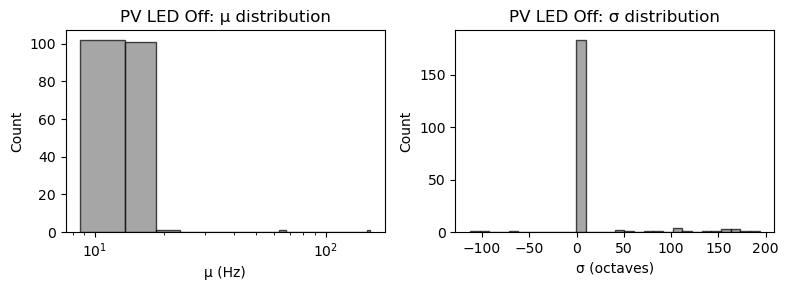

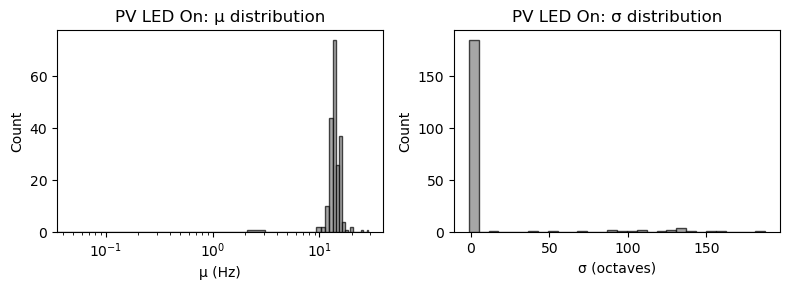

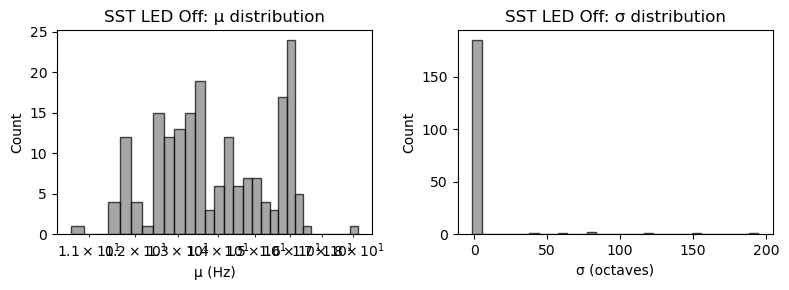

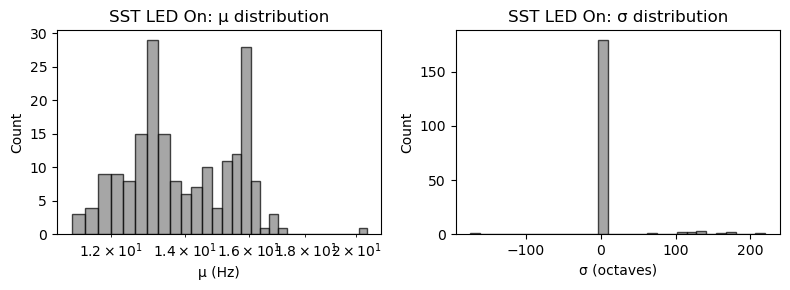

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fit_histograms(results, label, bins_mu=30, bins_sigma=30):
    """
    Plot histograms of mu and sigma from Gaussian fits.

    Parameters
    ----------
    results : pd.DataFrame
        DataFrame with at least 'mu' and 'sigma' columns (mu is in octaves).
    label : str
        Label for the condition (e.g., 'LED Off', 'LED On').
    bins_mu, bins_sigma : int
        Number of bins for histograms.
    """
    # Convert mu (octaves) → Hz for interpretability
    mu_hz = results['mu'].dropna()
    sigma = results['sigma'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    # μ histogram (Hz, log scale on x-axis)
    axes[0].hist(mu_hz, bins=bins_mu, color='gray', edgecolor='black', alpha=0.7)
    axes[0].set_xscale('log')
    axes[0].set_xlabel('μ (Hz)')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'{label}: μ distribution')

    # σ histogram (octaves)
    axes[1].hist(sigma, bins=bins_sigma, color='gray', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('σ (octaves)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'{label}: σ distribution')

    fig.tight_layout()
    plt.show()


# Example usage:
plot_fit_histograms(PV_results_off, "PV LED Off")
plot_fit_histograms(PV_results_on, "PV LED On")
plot_fit_histograms(SST_results_off, "SST LED Off")
plot_fit_histograms(SST_results_on, "SST LED On")


# Plotting mu and sigma changes for suppressed/facilitated cells

# Try out fit params

In [10]:
import numpy as np
import pandas as pd

def summarize_good_fits(
    results_off: pd.DataFrame,
    results_on: pd.DataFrame,
    facilitated_idx: list,
    suppressed_idx: list,
    uniq_freq: np.ndarray,
    label: str,
    r2_min: float = 0.6,
    sigma_cap_oct: float = 4.0,
    pad_oct: float = 0.25,
    min_sigma: float = 1e-6,
    only_success: bool = True,
):
    """
    Summarize how many cells in each group have good Gaussian fits,
    with filtering consistently in octaves.
    """

    # tested range (Hz -> octaves)
    octaves = np.log2(np.asarray(uniq_freq, dtype=float))
    lo_oct = float(octaves.min() - pad_oct)
    hi_oct = float(octaves.max() + pad_oct)

    def count_good(df, idx):
        subset = df[df['cell'].isin(idx)].copy()

        # Apply constraints
        mask = subset['r2'] > r2_min
        if only_success and 'success' in subset.columns:
            mask &= subset['success'].fillna(False)

        # Mu in octaves
        mask &= subset['mu'].between(lo_oct, hi_oct)

        # Sigma constraints (octaves)
        mask &= (subset['sigma'] > min_sigma) & (subset['sigma'] <= sigma_cap_oct)

        subset = subset[mask]
        return len(subset), len(df[df['cell'].isin(idx)])

    print(f"\n=== {label} Summary ===")

    # Facilitated
    off_good, off_total = count_good(results_off, facilitated_idx)
    on_good,  on_total  = count_good(results_on,  facilitated_idx)
    print(f"Facilitated: LED Off {off_good}/{off_total},  LED On {on_good}/{on_total}")

    # Suppressed
    off_good, off_total = count_good(results_off, suppressed_idx)
    on_good,  on_total  = count_good(results_on,  suppressed_idx)
    print(f"Suppressed:  LED Off {off_good}/{off_total},  LED On {on_good}/{on_total}")


In [11]:
summarize_good_fits(
    results_off=PV_results_off,
    results_on=PV_results_on,
    facilitated_idx=PV_facilitated_Ind,
    suppressed_idx=PV_suppressed_Ind,
    uniq_freq=uniq_Freq,   # your tested freqs in Hz
    label="PV",
    r2_min=0.6,
    sigma_cap_oct=4.0,
    pad_oct=0.25,
    min_sigma=1e-6,
    only_success=True
)

summarize_good_fits(
    results_off=SST_results_off,
    results_on=SST_results_on,
    facilitated_idx=SST_facilitated_Ind,
    suppressed_idx=SST_suppressed_Ind,
    uniq_freq=uniq_Freq,   # your tested freqs in Hz
    label="SST",
    r2_min=0.6,
    sigma_cap_oct=4.0,
    pad_oct=0.25,
    min_sigma=1e-6,
    only_success=True
)



=== PV Summary ===
Facilitated: LED Off 26/85,  LED On 10/85
Suppressed:  LED Off 53/121,  LED On 38/121

=== SST Summary ===
Facilitated: LED Off 5/21,  LED On 7/21
Suppressed:  LED Off 67/171,  LED On 60/171


# Inspect specific group

In [12]:
def inspect_group(
    results_df: pd.DataFrame,
    cell_idx: list,
    uniq_freq,
    label: str,
    r2_min: float = 0.6,
    sigma_cap_oct: float = 4.0,
    pad_oct: float = 0.25,
    min_sigma: float = 1e-6,
    only_success: bool = True
):
    """
    Print detailed info (R², μ, σ) for a group of cells under a single condition.

    Parameters
    ----------
    results_df : pd.DataFrame
        The results table (either LED off or LED on).
        Must have columns ['cell','r2','mu','sigma','success'].
        Note: 'mu' should be in OCTAVES.
    cell_idx : list
        Cell indices (e.g., SST_facilitated_Ind).
    uniq_freq : array
        Tested freqs in Hz.
    label : str
        Label for this group (e.g. "SST facilitated, LED On").
    Other params
        Thresholds for filtering.
    """

    octaves = np.log2(np.asarray(uniq_freq, dtype=float))
    lo_oct = float(octaves.min() - pad_oct)
    hi_oct = float(octaves.max() + pad_oct)

    # Subset
    subset = results_df[results_df['cell'].isin(cell_idx)].copy()
    
    # Constraints
    mask = (subset['r2'] > r2_min)
    if only_success and 'success' in subset.columns:
        mask &= subset['success'].fillna(False)
    mask &= subset['mu'].between(lo_oct, hi_oct)
    mask &= (subset['sigma'] > min_sigma) & (subset['sigma'] <= sigma_cap_oct)

    kept = subset.loc[mask]
    dropped = subset.loc[~mask]

    print(f"\n=== {label} ===")
    print(f"Total cells in group: {len(subset)}")
    print(f"Kept (pass filters): {len(kept)}")
    print(f"Dropped (fail filters): {len(dropped)}")

    if not kept.empty:
        print("\n-- Kept cells --")
        print(kept[['cell','r2','mu','sigma']].to_string(index=False))
    if not dropped.empty:
        print("\n-- Dropped cells --")
        print(dropped[['cell','r2','mu','sigma']].to_string(index=False))

    return kept, dropped


In [13]:
# Inspect SST facilitated, LED on
inspect_group(
    results_df=SST_results_off,
    cell_idx=SST_facilitated_Ind,
    uniq_freq=uniq_Freq,
    label="SST suppressed (LED On)"
)



=== SST suppressed (LED On) ===
Total cells in group: 21
Kept (pass filters): 5
Dropped (fail filters): 16

-- Kept cells --
 cell       r2        mu    sigma
   90 0.836077 13.053171 0.435670
   91 0.924721 13.336043 0.405039
  158 0.875622 14.755356 0.400631
  159 0.799292 14.566265 2.055611
  170 0.883640 15.935708 0.067496

-- Dropped cells --
 cell       r2        mu     sigma
   49 0.582463 15.923222  0.064205
   59 0.431832 13.234621  0.151621
   74 0.402047 14.438342  0.241215
   88 0.398261 12.563195  0.797895
  134 0.341246 12.425693  0.071371
  136 0.295985 13.432013  0.063719
  146 0.445436 15.452396  0.059934
  147 0.560675 15.103551  0.146326
  149 0.396784 13.144231  0.618945
  152 0.222980 12.578403 -0.032579
  166 0.574467 15.694719  0.113766
  167 0.566165 15.739560  0.149118
  168 0.428046 13.423874  0.251771
  169 0.457419 15.950312  0.069092
  172 0.463223 12.827781 -0.529995
  179 0.576949 15.935918  0.064988


(     cell           a         mu     sigma   baseline        r2  success
 90     90   19.710637  13.053171  0.435670   5.157229  0.836077     True
 91     91   32.257077  13.336043  0.405039   5.459089  0.924721     True
 158   158   37.397152  14.755356  0.400631  19.114378  0.875622     True
 159   159  -40.902401  14.566265  2.055611  49.292844  0.799292     True
 170   170  167.126797  15.935708  0.067496   5.985212  0.883640     True,
      cell           a         mu     sigma   baseline        r2  success
 49     49  114.141575  15.923222  0.064205   4.119385  0.582463     True
 59     59    6.690233  13.234621  0.151621   3.040166  0.431832     True
 74     74   32.944921  14.438342  0.241215  22.821676  0.402047     True
 88     88   10.608976  12.563195  0.797895  14.037457  0.398261     True
 134   134   26.670518  12.425693  0.071371   4.253229  0.341246     True
 136   136   35.536120  13.432013  0.063719   3.737677  0.295985     True
 146   146   34.614211  15.452396  0.

# shared plots

In [14]:
# Axis stuff
# middle frequency tested
print(uniq_Freq)
print(np.round(np.median(uniq_Freq)))

[ 3000  3568  4243  5045  6000  7135  8485 10091 12000 14270 16971 20182
 24000 28541 33941 40363 48000 57082 67882]
14270.0


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import ttest_rel, wilcoxon
from matplotlib.ticker import ScalarFormatter

def build_mu_sigma_subset(
    results_off: pd.DataFrame,
    results_on: pd.DataFrame,
    uniq_freq,                 # array of tested freqs in Hz
    r2_min: float = 0.6,
    sigma_cap_oct: float = 8.0,
    only_success: bool = True,
    pad_oct: float = 0.25,
    min_sigma: float = 1e-6
) -> pd.DataFrame:
    """
    Return a merged DataFrame with the SAME filtered cells for μ and σ plots.
    Keeps rows where BOTH conditions satisfy:
      - r2 > r2_min
      - (optionally) success == True
      - mu within tested octave range (±pad_oct)
      - 0 < sigma <= sigma_cap_oct
    """
    # Merge the essentials
    df = (
        results_off[['cell','mu','sigma','r2','success']].rename(
            columns={'mu':'mu_off','sigma':'sigma_off','r2':'r2_off','success':'success_off'}
        )
        .merge(
            results_on[['cell','mu','sigma','r2','success']].rename(
                columns={'mu':'mu_on','sigma':'sigma_on','r2':'r2_on','success':'success_on'}
            ),
            on='cell', how='inner'
        )
    )

    # Tested range in octaves
    octaves = np.log2(np.asarray(uniq_freq, dtype=float))
    lo_oct = float(octaves.min() - pad_oct)
    hi_oct = float(octaves.max() + pad_oct)

    # Base mask: R^2 (both)
    mask = (df['r2_off'] > r2_min) & (df['r2_on'] > r2_min)

    # require success in both
    if only_success:
        mask &= df['success_off'].fillna(False) & df['success_on'].fillna(False)

    # Mu within tested band (both) 
    mask &= df['mu_off'].between(lo_oct, hi_oct) & df['mu_on'].between(lo_oct, hi_oct)

    # Sigma within (0, sigma_cap] (both)
    mask &= (df['sigma_off'] > min_sigma) & (df['sigma_off'] <= sigma_cap_oct)
    mask &= (df['sigma_on']  > min_sigma) & (df['sigma_on']  <= sigma_cap_oct)

    df_sub = df.loc[mask].copy()
    df_sub['mu_off_Hz'] = np.power(2.0, df_sub['mu_off'])
    df_sub['mu_on_Hz']  = np.power(2.0, df_sub['mu_on'])

    # plot limits in Hz
    lo_hz, hi_hz = float(2**lo_oct), float(2**hi_oct)
    df_sub.attrs['limits'] = dict(lo_oct=lo_oct, hi_oct=hi_oct, lo_hz=lo_hz, hi_hz=hi_hz)

    print(f"Subset: kept {len(df_sub)} / {len(df)} cells "
          f"(R^2>{r2_min}, 0<σ≤{sigma_cap_oct:.2f} oct"
          f"{', success only' if only_success else ''}).")
    return df_sub

def plot_mu_from_subset(
    df_sub: pd.DataFrame,
    title: str,
    pdf_path: str | None = None,
    font_family: str = "Arial",
    font_size: int = 10
):
    """Scatter of μ in Hz (log-log) using the shared filtered subset."""
    lims = df_sub.attrs.get('limits', {})
    lo_hz = lims.get('lo_hz', float(df_sub[['mu_off_Hz','mu_on_Hz']].min().min()))
    hi_hz = lims.get('hi_hz', float(df_sub[['mu_off_Hz','mu_on_Hz']].max().max()))

    with mpl.rc_context({
    'font.family': font_family,
    'font.size': font_size,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
        }):
        fig, ax = plt.subplots(figsize=(3,3))
        ax.scatter(df_sub['mu_off_Hz'], df_sub['mu_on_Hz'], s=40, alpha=0.40, color='black', edgecolors='none')
        ax.plot([lo_hz, hi_hz], [lo_hz, hi_hz], '--', color='gray', lw=1)
        ax.set_xlim(lo_hz, hi_hz); ax.set_ylim(lo_hz, hi_hz)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('μ Light Off (Hz)')
        ax.set_ylabel('μ Light On (Hz)')
        ax.set_title(title)
        fig.tight_layout()


        # set ticks to just 3 values
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(axis='x', which='minor', bottom=False)
        ax.tick_params(axis='y', which='minor', left=False) # Disable auto ticks

        custom_ticks = [np.min(uniq_Freq), np.median(uniq_Freq), np.max(uniq_Freq)]
        ax.set_xticks(custom_ticks)
        ax.set_yticks(custom_ticks)

        # Set up the tick labels
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        formatter.set_useOffset(False)

        # format them nicely
        ax.xaxis.set_major_formatter(formatter)
        ax.yaxis.set_major_formatter(formatter)

        # Save fig
        if pdf_path:
            fig.savefig(pdf_path, format='pdf')
        
        plt.show()

        # run the statistics
        paired = df_sub[['mu_off_Hz', 'mu_on_Hz']].dropna()
        x = paired['mu_off_Hz']
        y = paired['mu_on_Hz']

        t_stat, p_val = ttest_rel(x, y)
        # t_stat, p_val = wilcoxon(x, y)

        # Print the results
        print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.3e}")
        if p_val < 0.05:
            print('*')


def plot_sigma_from_subset(
    df_sub: pd.DataFrame,
    title: str,
    pdf_path: str | None = None,
    font_family: str = "Arial",
    font_size: int = 10,
    as_fwhm: bool = False
):
    """Scatter of σ (octaves) or FWHM (octaves) using the same filtered subset."""
    with mpl.rc_context({
    'font.family': font_family,
    'font.size': font_size,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
        }):
        x = df_sub['sigma_off'].to_numpy(copy=True)
        y = df_sub['sigma_on'].to_numpy(copy=True)
        label = 'σ (octaves)'

        if as_fwhm:
            factor = 2.354820045  # FWHM = 2.3548 * sigma
            x *= factor; y *= factor
            label = 'FWHM (octaves)'

        # Limits: 0 to cap used in subset (or converted cap if FWHM)
        lims = df_sub.attrs.get('limits', {})
        # We didn’t store sigma cap in attrs; infer from actual data so both axes match
        max_val = float(max(x.max(), y.max()))
        lim0 = 0.0
        # lim1 = max(1.0, np.ceil(max_val*20)/20)  # a little space on either side
        lim1 = 4 # instead set to 4 octaves

        fig, ax = plt.subplots(figsize=(3,3))
        ax.scatter(x, y, s=40, alpha=0.40, color='black', edgecolors='none')

        ax.plot([lim0, lim1], [lim0, lim1], '--', color='gray', lw=1)
        ax.set_xlim(lim0, lim1)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('σ Light Off (octaves)')
        ax.set_ylabel('σ Light On (octaves)')
        ax.set_title(title)
        fig.tight_layout()
        if pdf_path:
            fig.savefig(pdf_path, format='pdf')
        plt.show()

        t_stat, p_val = ttest_rel(x, y)

        # Print the results
        print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.3e}")
        if p_val < 0.05:
            print('*')


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

def plot_paired_bar_swarm(
    df_sub: pd.DataFrame,
    off_col: str, on_col: str,   # 'mu_off_Hz', 'mu_on_Hz'  OR  'sigma_off', 'sigma_on'
    off_color: str, on_color: str, # add these to function call to make the colors diff per plot
    y_label: str,
    title: str,
    log_y: bool = False,
    pdf_path: str | None = None,
    font_family: str = "Arial",
    font_size: int = 10
):
    """
    Bar (mean ± SE) with beeswarm overlay for paired OFF vs ON data.
    Expects df_sub to contain 'cell', plus the two value columns.
    """

    with mpl.rc_context({
    'font.family': font_family,
    'font.size': font_size,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
        }):
        # Long format for seaborn
        long = df_sub[['cell', off_col, on_col]].melt(
            id_vars='cell', var_name='condition', value_name='value'
        )
        # Normalize labels: *_off / *_on
        long['condition'] = long['condition'].map(
            {off_col: 'Off', on_col: 'On'}
        )

        # Figure
        fig, ax = plt.subplots(figsize=(1.5, 3))

        # Bar (mean ± SE)
        sns.boxplot(
            data=long, x='condition', y='value',
            palette={'Off': off_color, 'On': on_color},
            fliersize=0,      # hide default outlier markers
            linewidth=1,      # outline thickness
            ax=ax
        )

        # Strip plot
        sns.stripplot(
            data=long, x='condition', y='value',
            color='black', alpha=0.5, size=5,
            jitter=True, dodge=True, edgecolor='none', ax=ax
        )

        # Beeswarm overlay: black, alpha 0.25, no edge
        # sns.swarmplot(
            # data=long, x='condition', y='value',
            # color='black', alpha=1, size=4, edgecolor='none', ax=ax
        # )

        # Axis settings
        if log_y:
            ax.set_yscale('log')
            lims = df_sub.attrs.get('limits', {})
            lo_hz, hi_hz = lims.get('lo_hz', None), lims.get('hi_hz', None)
            if lo_hz and hi_hz:
                ax.set_ylim(lo_hz, hi_hz)
                # set ticks to just 3 values
                ax.set_yscale('log')
                ax.tick_params(axis='y', which='minor', left=False) # Disable auto ticks

                custom_ticks = [np.min(uniq_Freq), np.median(uniq_Freq), np.max(uniq_Freq)]
                ax.set_yticks(custom_ticks)

                # Set up the tick labels
                formatter = ScalarFormatter()
                formatter.set_scientific(False)
                formatter.set_useOffset(False)

                # format them nicely
                ax.yaxis.set_major_formatter(formatter)

        ax.set_xlabel('')
        ax.set_ylabel(y_label)
        ax.set_title(title)
        fig.tight_layout()

        if pdf_path:
            fig.savefig(pdf_path, format='pdf')  # vector, Illustrator-editable
        plt.show()


Subset: kept 6 / 85 cells (R^2>0.6, 0<σ≤4.00 oct, success only).


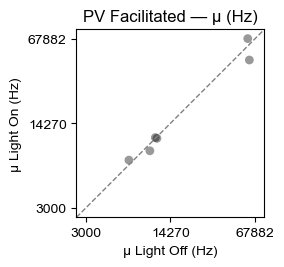

Paired t-test: t = 0.386, p = 7.150e-01


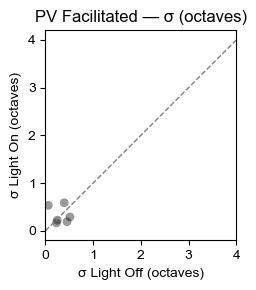

Paired t-test: t = -0.129, p = 9.026e-01


/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2367972554.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


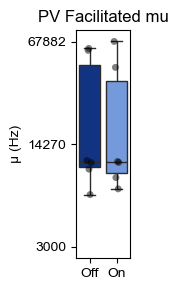

/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2367972554.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


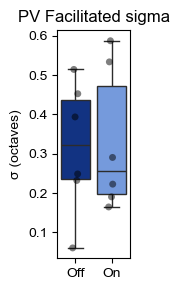

Subset: kept 27 / 121 cells (R^2>0.6, 0<σ≤4.00 oct, success only).


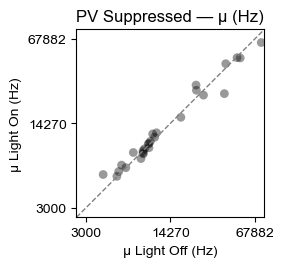

Paired t-test: t = 0.821, p = 4.191e-01


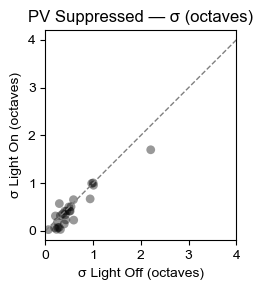

Paired t-test: t = 3.181, p = 3.772e-03
*


/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2367972554.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


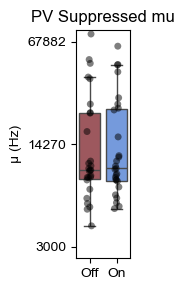

/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2367972554.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


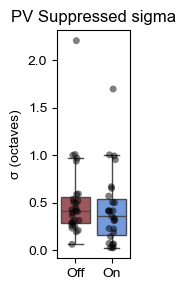

Subset: kept 5 / 21 cells (R^2>0.6, 0<σ≤4.00 oct, success only).


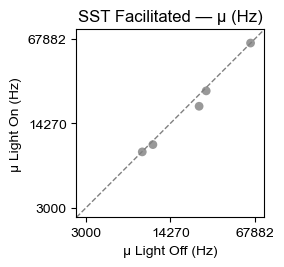

Paired t-test: t = 1.564, p = 1.928e-01


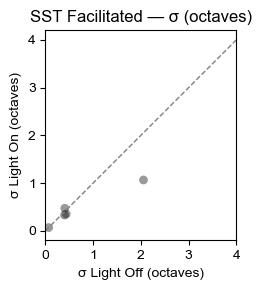

Paired t-test: t = 1.105, p = 3.312e-01


/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2367972554.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


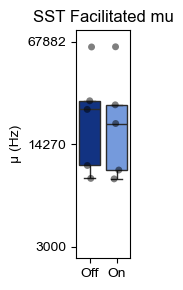

/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2367972554.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


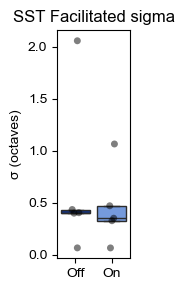

Subset: kept 38 / 171 cells (R^2>0.6, 0<σ≤4.00 oct, success only).


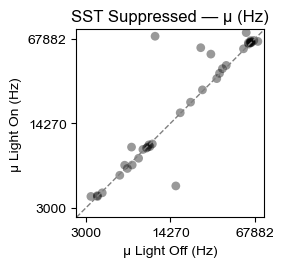

Paired t-test: t = -1.760, p = 8.670e-02


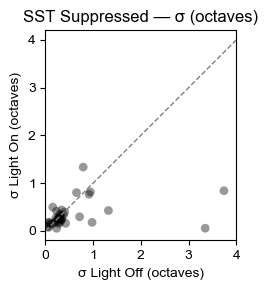

Paired t-test: t = 1.787, p = 8.215e-02


/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2367972554.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


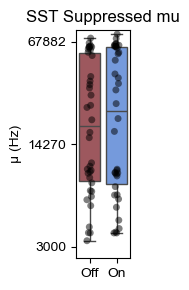

/var/folders/dg/7pr6dd5x71d9fsn8g5t932kc0000gn/T/ipykernel_78007/2367972554.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


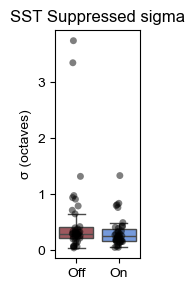

In [17]:
# PV facilitated group
pv_fac_off = PV_results_off[PV_results_off['cell'].isin(PV_facilitated_Ind)]
pv_fac_on  = PV_results_on[PV_results_on['cell'].isin(PV_facilitated_Ind)]

pv_fac_subset = build_mu_sigma_subset(
    pv_fac_off, pv_fac_on, uniq_Freq,
    r2_min=0.6, sigma_cap_oct=4, only_success=True, pad_oct=0.25
)

plot_mu_from_subset(pv_fac_subset,  title='PV Facilitated — μ (Hz)',     pdf_path='PV_fac_mu.pdf')
plot_sigma_from_subset(pv_fac_subset, title='PV Facilitated — σ (octaves)', pdf_path='PV_fac_sigma.pdf')

plot_paired_bar_swarm(
    pv_fac_subset,
    off_col='mu_off_Hz', on_col='mu_on_Hz',
    off_color='#002c94', on_color='CornflowerBlue',
    y_label='μ (Hz)',
    title='PV Facilitated mu',
    log_y=True,
    pdf_path='PV_Facilitated_mu_bar_swarm.pdf'
)

plot_paired_bar_swarm(
    pv_fac_subset,
    off_col='sigma_off', on_col='sigma_on',
    off_color='#002c94', on_color='CornflowerBlue',
    y_label='σ (octaves)',
    title='PV Facilitated sigma',
    log_y=False,
    pdf_path='PV_Facilitated_sigma_bar_swarm.pdf'
)

# PV suppressed group
pv_sup_off = PV_results_off[PV_results_off['cell'].isin(PV_suppressed_Ind)]
pv_sup_on  = PV_results_on[PV_results_on['cell'].isin(PV_suppressed_Ind)]
pv_sup_subset = build_mu_sigma_subset(
    pv_sup_off, pv_sup_on, uniq_Freq,
    r2_min=0.6, sigma_cap_oct=4, only_success=True, pad_oct=0.25
)
plot_mu_from_subset(pv_sup_subset,  title='PV Suppressed — μ (Hz)', pdf_path='PV_sup_mu.pdf')
plot_sigma_from_subset(pv_sup_subset, title='PV Suppressed — σ (octaves)', pdf_path='PV_sup_sigma.pdf')

plot_paired_bar_swarm(
    pv_sup_subset,
    off_col='mu_off_Hz', on_col='mu_on_Hz',
    off_color='#A94C54', on_color='CornflowerBlue',
    y_label='μ (Hz)',
    title='PV Suppressed mu',
    log_y=True,
    pdf_path='PV_Suppressed_mu_bar_swarm.pdf'
)

plot_paired_bar_swarm(
    pv_sup_subset,
    off_col='sigma_off', on_col='sigma_on',
    off_color='#A94C54', on_color='CornflowerBlue',
    y_label='σ (octaves)',
    title='PV Suppressed sigma',
    log_y=False,
    pdf_path='PV_Suppressed_sigma_bar_swarm.pdf'
)

# SST facilitated group
sst_fac_off = SST_results_off[SST_results_off['cell'].isin(SST_facilitated_Ind)]
sst_fac_on  = SST_results_on[SST_results_on['cell'].isin(SST_facilitated_Ind)]
sst_fac_subset = build_mu_sigma_subset(
    sst_fac_off, sst_fac_on, uniq_Freq,
    r2_min=0.6, sigma_cap_oct=4, only_success=True, pad_oct=0.25
)
plot_mu_from_subset(sst_fac_subset,  title='SST Facilitated — μ (Hz)', pdf_path='SST_fac_mu.pdf')
plot_sigma_from_subset(sst_fac_subset, title='SST Facilitated — σ (octaves)', pdf_path='SST_fac_sigma.pdf')

plot_paired_bar_swarm(
    sst_fac_subset,
    off_col='mu_off_Hz', on_col='mu_on_Hz',
    off_color='#002c94', on_color='CornflowerBlue',
    y_label='μ (Hz)',
    title='SST Facilitated mu',
    log_y=True,
    pdf_path='SST_Facilitated_mu_bar_swarm.pdf'
)

plot_paired_bar_swarm(
    sst_fac_subset,
    off_col='sigma_off', on_col='sigma_on',
    off_color='#002c94', on_color='CornflowerBlue',
    y_label='σ (octaves)',
    title='SST Facilitated sigma',
    log_y=False,
    pdf_path='SST_Facilitated_sigma_bar_swarm.pdf'
)

# SST suppressed group
sst_sup_off = SST_results_off[SST_results_off['cell'].isin(SST_suppressed_Ind)]
sst_sup_on  = SST_results_on[SST_results_on['cell'].isin(SST_suppressed_Ind)]
sst_sup_subset = build_mu_sigma_subset(
    sst_sup_off, sst_sup_on, uniq_Freq,
    r2_min=0.6, sigma_cap_oct=4, only_success=True, pad_oct=0.25
)
plot_mu_from_subset(sst_sup_subset,  title='SST Suppressed — μ (Hz)', pdf_path='SST_sup_mu.pdf')
plot_sigma_from_subset(sst_sup_subset, title='SST Suppressed — σ (octaves)', pdf_path='SST_sup_sigma.pdf')

plot_paired_bar_swarm(
    sst_sup_subset,
    off_col='mu_off_Hz', on_col='mu_on_Hz',
    off_color='#A94C54', on_color='CornflowerBlue',
    y_label='μ (Hz)',
    title='SST Suppressed mu',
    log_y=True,
    pdf_path='SST_Suppressed_mu_bar_swarm.pdf'
)

plot_paired_bar_swarm(
    sst_sup_subset,
    off_col='sigma_off', on_col='sigma_on',
    off_color='#A94C54', on_color='CornflowerBlue',
    y_label='σ (octaves)',
    title='SST Suppressed sigma',
    log_y=False,
    pdf_path='SST_Suppressed_sigma_bar_swarm.pdf'
)


# Summarize the fits

In [18]:
def summarize_good_fits(results_off, results_on, facilitated_idx, suppressed_idx, label):
    """
    Summarize how many cells in a condition had good Gaussian fits (R² > 0.6).

    Parameters
    ----------
    results_off : pd.DataFrame
        Results dataframe for LED off.
    results_on : pd.DataFrame
        Results dataframe for LED on.
    facilitated_idx : list
        Cell indices for facilitated group.
    suppressed_idx : list
        Cell indices for suppressed group.
    label : str
        Label for this population (e.g. "PV", "SST")
    """

    def count_good(df, idx):
        subset = df[df['cell'].isin(idx)]
        n_total = len(subset)
        n_good = np.sum(subset['r2'] > 0.6)
        return n_good, n_total

    print(f"\n=== {label} Summary ===")

    # Facilitated
    off_good, off_total = count_good(results_off, facilitated_idx)
    on_good, on_total   = count_good(results_on, facilitated_idx)
    print(f"Facilitated:  LED Off {off_good}/{off_total},  LED On {on_good}/{on_total}")

    # Suppressed
    off_good, off_total = count_good(results_off, suppressed_idx)
    on_good, on_total   = count_good(results_on, suppressed_idx)
    print(f"Suppressed:  LED Off {off_good}/{off_total},  LED On {on_good}/{on_total}")


# Example usage:
summarize_good_fits(PV_results_off, PV_results_on, PV_facilitated_Ind, PV_suppressed_Ind, label="PV")
summarize_good_fits(SST_results_off, SST_results_on, SST_facilitated_Ind, SST_suppressed_Ind, label="SST")



=== PV Summary ===
Facilitated:  LED Off 31/85,  LED On 11/85
Suppressed:  LED Off 60/121,  LED On 47/121

=== SST Summary ===
Facilitated:  LED Off 5/21,  LED On 10/21
Suppressed:  LED Off 74/171,  LED On 71/171


# Compare statistical tests

In [19]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon

def _prep_pairs(df, off_col, on_col):
    """Return paired arrays x (off), y (on) with NaNs/Infs removed and aligned."""
    pairs = df[[off_col, on_col]].replace([np.inf, -np.inf], np.nan).dropna()
    x = pairs[off_col].to_numpy()
    y = pairs[on_col].to_numpy()
    return x, y

def _paired_effect_sizes(x, y):
    """Cohen's dz for paired data and summary diffs."""
    d = y - x
    n = d.size
    mean_diff = float(np.mean(d)) if n else np.nan
    median_diff = float(np.median(d)) if n else np.nan
    sd_diff = float(np.std(d, ddof=1)) if n > 1 else np.nan
    dz = mean_diff / sd_diff if (sd_diff and np.isfinite(sd_diff) and sd_diff > 0) else np.nan
    return n, mean_diff, median_diff, dz

def paired_tests_table(groups: dict, off_col: str, on_col: str) -> pd.DataFrame:
    """
    groups: dict like {"PV suppressed": df_sub_sup, "PV facilitated": df_sub_fac, ...}
            Each df must contain off_col & on_col (e.g., 'mu_off_Hz','mu_on_Hz').
    Returns a DataFrame with t-test and Wilcoxon results per group.
    """
    rows = []
    for name, df in groups.items():
        x, y = _prep_pairs(df, off_col, on_col)
        n, mean_diff, median_diff, dz = _paired_effect_sizes(x, y)

        # default placeholders
        t_stat = t_p = w_stat = w_p = np.nan

        if n >= 2:
            # Paired t-test
            t_stat, t_p = ttest_rel(x, y, nan_policy='omit')

            # Wilcoxon signed-rank (paired, nonparametric)
            # Handle the case where all diffs are zero (scipy raises ValueError)
            try:
                # zero_method='wilcox' ignores zero-diffs; two-sided by default
                w_stat, w_p = wilcoxon(x, y, zero_method='wilcox', alternative='two-sided', method='auto')
            except ValueError:
                w_stat, w_p = np.nan, np.nan

        rows.append({
            "group": name,
            "n_pairs": n,
            "mean_diff": mean_diff,      # on - off
            "median_diff": median_diff,  # on - off
            "cohens_dz": dz,
            "t_stat": t_stat, "t_p": t_p,
            "W_stat": w_stat, "W_p": w_p,
        })

    table = pd.DataFrame(rows)
    # Optional: order columns nicely
    table = table[["group","n_pairs","mean_diff","median_diff","cohens_dz","t_stat","t_p","W_stat","W_p"]]
    return table


In [20]:
groups_mu = {
    "PV suppressed":   pv_sup_subset,   # has columns 'mu_off_Hz','mu_on_Hz'
    "PV facilitated":  pv_fac_subset,
    "SST suppressed":  sst_sup_subset,
    "SST facilitated": sst_fac_subset,
}

mu_table = paired_tests_table(groups_mu, off_col="mu_off_Hz", on_col="mu_on_Hz")
print(mu_table)

# For sigma (octaves):
groups_sigma = {
    "PV suppressed":   pv_sup_subset,
    "PV facilitated":  pv_fac_subset,
    "SST suppressed":  sst_sup_subset,
    "SST facilitated": sst_fac_subset,
}
sigma_table = paired_tests_table(groups_sigma, off_col="sigma_off", on_col="sigma_on")
print(sigma_table)

# Save to Excel
mu_table.to_excel("mu_comparison_table.xlsx", index=False)
sigma_table.to_excel("sigma_comparison_table.xlsx", index=False)


             group  n_pairs    mean_diff  median_diff  cohens_dz    t_stat  \
0    PV suppressed       27  -649.342555    65.319768  -0.157990  0.820940   
1   PV facilitated        6 -1230.274764   -66.818127  -0.157780  0.386480   
2   SST suppressed       38  3410.329019   320.480601   0.285482 -1.759830   
3  SST facilitated        5 -1382.186547  -689.810946  -0.699652  1.564469   

        t_p  W_stat       W_p  
0  0.419144   176.0  0.767608  
1  0.715041     9.0  0.843750  
2  0.086703   222.0  0.030713  
3  0.192756     2.0  0.187500  
             group  n_pairs  mean_diff  median_diff  cohens_dz    t_stat  \
0    PV suppressed       27  -0.097957    -0.067002  -0.612266  3.181429   
1   PV facilitated        6   0.014544    -0.046659   0.052522 -0.128651   
2   SST suppressed       38  -0.212649    -0.017204  -0.289872  1.786893   
3  SST facilitated        5  -0.216058    -0.072330  -0.494123  1.104892   

        t_p  W_stat       W_p  
0  0.003772    67.0  0.002469  
1  0

# Plot FRFs for each group

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_centered_rf_by_mu(mTCOff, mTCOn, uniq_Freq, df_subset,
                           title="", pdf_path=None, align_to="off",
                           off_color="black", on_color="CornflowerBlue"):
    """
    Center each cell's tuning curve on its fitted mu (from df_subset),
    then plot mean OFF vs ON with SEM shading.

    df_subset must have columns: 'cell', 'mu_off_Hz', 'mu_on_Hz'
    mTCOff / mTCOn shape: (n_freq, n_cells) or (n_cells, n_freq)
    uniq_Freq: array of tested freqs in Hz (log-spaced preferred)
    align_to: 'off' (use mu_off_Hz) or 'on' (use mu_on_Hz)
    """
    # ensure freq x cell
    if mTCOff.shape[0] != len(uniq_Freq):
        mTCOff = mTCOff.T
    if mTCOn.shape[0] != len(uniq_Freq):
        mTCOn = mTCOn.T

    cells = df_subset["cell"].to_numpy(dtype=int)
    mu_hz = (df_subset["mu_off_Hz"] if align_to == "off" else df_subset["mu_on_Hz"]).to_numpy(dtype=float)

    # common x-grid in octaves (same # points as uniq_Freq, centered at 0)
    logF = np.log2(np.asarray(uniq_Freq, dtype=float))
    step = np.median(np.diff(logF))
    nF = len(logF)
    half = (nF - 1) / 2.0
    x_oct = (np.arange(nF) - half) * step  # e.g., [-K..0..+K]*step

    # collect centered curves (NaN outside the sampled range)
    off_centered = []
    on_centered  = []

    for c, mu in zip(cells, mu_hz):
        x_cell = logF - np.log2(mu)           # octaves from that cell's μ
        y_off  = mTCOff[:, c].astype(float)
        y_on   = mTCOn[:,  c].astype(float)

        y_off_c = np.interp(x_oct, x_cell, y_off, left=np.nan, right=np.nan)
        y_on_c  = np.interp(x_oct, x_cell, y_on,  left=np.nan, right=np.nan)

        off_centered.append(y_off_c)
        on_centered.append(y_on_c)

    off_centered = np.vstack(off_centered)
    on_centered  = np.vstack(on_centered)

    # mean ± SEM ignoring NaNs
    def nansem(a, axis=0):
        n = np.sum(~np.isnan(a), axis=axis)
        return np.nanstd(a, axis=axis, ddof=1) / np.sqrt(np.maximum(n, 1))

    mean_off = np.nanmean(off_centered, axis=0); sem_off = nansem(off_centered, axis=0)
    mean_on  = np.nanmean(on_centered,  axis=0); sem_on  = nansem(on_centered,  axis=0)

    with mpl.rc_context({
        'font.family': 'Arial',
        'font.size':   12,
        'pdf.fonttype': 42,
        'ps.fonttype':  42,
    }):
        fig, ax = plt.subplots(figsize=(2.2, 2.2))
        ax.plot(x_oct, mean_off, label="Off", color=off_color, lw=0.5)
        ax.fill_between(x_oct, mean_off - sem_off, mean_off + sem_off, alpha=0.25, color=off_color)
        ax.plot(x_oct, mean_on,  label="On",  color=on_color, lw=0.5)
        ax.fill_between(x_oct,  mean_on - sem_on,  mean_on + sem_on,  alpha=0.25, color=on_color)

        ax.axvline(0, lw=1, ls="--", color="k", alpha=0.5)
        ax.set_xlabel("Octaves from μ")
        ax.set_ylabel("Firing rate (Hz)")
        ax.set_title(title)
        ax.legend(frameon=False)
        fig.tight_layout()

        if pdf_path:
            fig.savefig(pdf_path, format="pdf")
        plt.show()


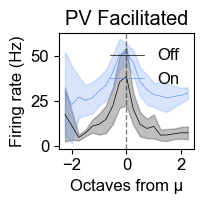

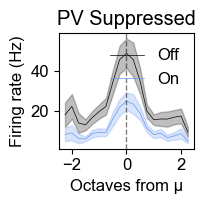

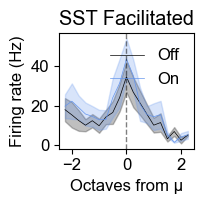

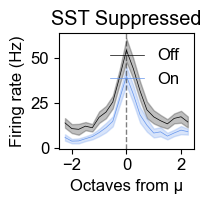

In [26]:
plot_centered_rf_by_mu(
    PV_mTCOff, PV_mTCOn, uniq_Freq, pv_fac_subset,
    title="PV Facilitated",
    pdf_path="PV_fac_centeredRF_byMu.pdf",
    align_to="off"   # or "on" to center by mu_on_Hz
)

plot_centered_rf_by_mu(
    PV_mTCOff, PV_mTCOn, uniq_Freq, pv_sup_subset,
    title="PV Suppressed",
    pdf_path="PV_supp_centeredRF_byMu.pdf",
    align_to="off"
)

plot_centered_rf_by_mu(
    SST_mTCOff, SST_mTCOn, uniq_Freq, sst_fac_subset,
    title="SST Facilitated",
    pdf_path="SST_fac_centeredRF_byMu.pdf",
    align_to="off"
)

plot_centered_rf_by_mu(
    SST_mTCOff, SST_mTCOn, uniq_Freq, sst_sup_subset,
    title="SST Suppressed",
    pdf_path="SST_supp_centeredRF_byMu.pdf",
    align_to="off"
)

# Generate output for the stats table

In [23]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, t, iqr

# ---------- helpers ----------
def _sem(sd: float, n: int) -> float:
    return sd / np.sqrt(n) if n > 0 else np.nan

def _moe(sem: float, n: int, alpha: float) -> float:
    # 95% MoE by default (uses t critical with df=n-1)
    if n <= 1 or np.isnan(sem):
        return np.nan
    tcrit = t.ppf(1 - alpha/2, df=n-1)
    return tcrit * sem

def _cohen_dz(diff: np.ndarray) -> float:
    # dz = mean(diff) / sd(diff), equivalent to t / sqrt(n)
    n = diff.size
    if n <= 1:
        return np.nan
    sd = diff.std(ddof=1)
    return np.mean(diff) / sd if sd > 0 else np.nan

def _hedges_gz_from_dz(dz: float, n: int) -> float:
    # small-sample correction for dz
    if n <= 2 or np.isnan(dz):
        return np.nan
    J = 1 - (3 / (4*n - 5))
    return dz * J

def summarize_paired(x: np.ndarray, y: np.ndarray, label: str,
                     alpha: float = 0.05, decimals: int = 3) -> pd.DataFrame:
    """
    Summarize Off vs On with paired t-test.
    Returns a tidy 1-row DataFrame with condition summaries + test results.
    """
    # keep only finite paired observations
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask].astype(float)
    y = y[mask].astype(float)
    n = x.size
    dfree = max(n - 1, 0)

    # per-condition descriptives
    off_mean   = float(np.mean(x)) if n else np.nan
    on_mean    = float(np.mean(y)) if n else np.nan
    off_median = float(np.median(x)) if n else np.nan
    on_median  = float(np.median(y)) if n else np.nan
    off_sd     = float(np.std(x, ddof=1)) if n > 1 else np.nan
    on_sd      = float(np.std(y, ddof=1)) if n > 1 else np.nan
    off_iqr    = float(iqr(x, rng=(25, 75))) if n else np.nan
    on_iqr     = float(iqr(y, rng=(25, 75))) if n else np.nan
    off_sem    = _sem(off_sd, n)
    on_sem     = _sem(on_sd, n)
    off_moe    = _moe(off_sem, n, alpha)
    on_moe     = _moe(on_sem, n, alpha)

    # paired differences (On - Off)
    diff       = y - x
    mean_diff  = float(np.mean(diff)) if n else np.nan
    median_diff= float(np.median(diff)) if n else np.nan
    sd_diff    = float(np.std(diff, ddof=1)) if n > 1 else np.nan
    sem_diff   = _sem(sd_diff, n)
    moe_diff   = _moe(sem_diff, n, alpha)
    ci_lo_diff = mean_diff - moe_diff if np.isfinite(moe_diff) else np.nan
    ci_hi_diff = mean_diff + moe_diff if np.isfinite(moe_diff) else np.nan

    # paired t-test
    if n > 1:
        t_stat, p_val = ttest_rel(y, x, nan_policy='omit')
    else:
        t_stat, p_val = np.nan, np.nan

    # effect sizes (paired)
    dz = _cohen_dz(diff) if n > 1 else np.nan
    gz = _hedges_gz_from_dz(dz, n) if n > 1 else np.nan

    out = pd.DataFrame([{
        "measure": label,
        "N_paired": n,
        # Off
        "off_mean": off_mean, "off_median": off_median, "off_sd": off_sd,
        "off_iqr": off_iqr, "off_sem": off_sem, "off_moe_95": off_moe,
        # On
        "on_mean": on_mean, "on_median": on_median, "on_sd": on_sd,
        "on_iqr": on_iqr, "on_sem": on_sem, "on_moe_95": on_moe,
        # Paired differences (On - Off)
        "mean_diff": mean_diff, "median_diff": median_diff, "sd_diff": sd_diff,
        "sem_diff": sem_diff, "moe_diff_95": moe_diff,
        "ci95_diff_lo": ci_lo_diff, "ci95_diff_hi": ci_hi_diff,
        # Test
        "t_stat": t_stat, "df": dfree, "p_value": p_val,
        # Effect sizes
        "cohen_dz": dz, "hedges_gz": gz
    }])

    # optional rounding for manuscript readability
    num_cols = out.select_dtypes(include=[float, int]).columns
    out[num_cols] = out[num_cols].apply(lambda s: s.round(decimals))
    return out

# ---------- main entry points ----------
def stats_table_from_subset(
    df_sub: pd.DataFrame,
    value: str = "mu",        # "mu" or "sigma"
    as_fwhm: bool = False,    # only used when value == "sigma"
    alpha: float = 0.05,
    decimals: int = 3
) -> pd.DataFrame:
    """
    Build a 1-row stats table for the chosen metric using your filtered df_sub.
    value="mu" uses columns 'mu_off_Hz' and 'mu_on_Hz'
    value="sigma" uses 'sigma_off' and 'sigma_on' (or FWHM if as_fwhm=True).
    """
    if value == "mu":
        x = df_sub["mu_off_Hz"].to_numpy()
        y = df_sub["mu_on_Hz"].to_numpy()
        label = "mu (Hz)"
    elif value == "sigma":
        x = df_sub["sigma_off"].to_numpy()
        y = df_sub["sigma_on"].to_numpy()
        if as_fwhm:
            # FWHM = 2.354820045 * sigma
            factor = 2.354820045
            x = x * factor
            y = y * factor
            label = "FWHM (oct)"
        else:
            label = "sigma (oct)"
    else:
        raise ValueError("value must be 'mu' or 'sigma'.")

    return summarize_paired(x, y, label=label, alpha=alpha, decimals=decimals)

def stats_table_both_mu_and_sigma(
    df_sub: pd.DataFrame,
    include_fwhm: bool = False,
    alpha: float = 0.05,
    decimals: int = 3
) -> pd.DataFrame:
    """Convenience wrapper: returns a multi-row table for mu and sigma (±FWHM)."""
    tables = [stats_table_from_subset(df_sub, value="mu", alpha=alpha, decimals=decimals),
              stats_table_from_subset(df_sub, value="sigma", as_fwhm=False, alpha=alpha, decimals=decimals)]
    if include_fwhm:
        tables.append(stats_table_from_subset(df_sub, value="sigma", as_fwhm=True, alpha=alpha, decimals=decimals))
    return pd.concat(tables, ignore_index=True)


In [24]:
all_groups_stats = pd.concat([
    stats_table_both_mu_and_sigma(pv_fac_subset, include_fwhm=True).assign(group="PV Facilitated"),
    stats_table_both_mu_and_sigma(pv_sup_subset, include_fwhm=True).assign(group="PV Suppressed"),
    stats_table_both_mu_and_sigma(sst_fac_subset, include_fwhm=True).assign(group="SST Facilitated"),
    stats_table_both_mu_and_sigma(sst_sup_subset, include_fwhm=True).assign(group="SST Suppressed")
], ignore_index=True)

print(all_groups_stats)

# Save to CSV for manuscript
all_groups_stats.to_csv("all_stats_table.csv", index=False)



        measure  N_paired   off_mean  off_median     off_sd    off_iqr  \
0       mu (Hz)         6  26536.629   10977.436  26299.660  37388.591   
1   sigma (oct)         6      0.317       0.321      0.168      0.201   
2    FWHM (oct)         6      0.746       0.756      0.395      0.474   
3       mu (Hz)        27  18256.191    9629.914  17869.773  14548.230   
4   sigma (oct)        27      0.527       0.416      0.421      0.274   
5    FWHM (oct)        27      1.240       0.980      0.991      0.645   
6       mu (Hz)         5  26687.268   24259.545  21796.132  17316.293   
7   sigma (oct)         5      0.673       0.405      0.787      0.035   
8    FWHM (oct)         5      1.585       0.954      1.854      0.083   
9       mu (Hz)        38  28689.176   18914.815  24005.606  49029.688   
10  sigma (oct)        38      0.539       0.297      0.775      0.196   
11   FWHM (oct)        38      1.268       0.699      1.825      0.462   

      off_sem  off_moe_95    on_mean 